# ***Gestión ambiental***

en este caso con el deterioro de la calidad de los cuerpos de agua y cómo, con el machine learning, se puede apoyar la implementación de mecanismos que permitan monitorear y evaluar las variaciones en las características fisicoquímicas del agua, con el fin de preservar la calidad de estos ecosistemas y garantizar la disponibilidad de agua dulce para la población humana.

**Objetivos:**
- Aplicar técnicas de clasificación basadas en árboles de
decisión y K-vecinos más cercanos para construir modelos predictivos que permitan estimar la calidad del agua de una zona determinada.

- Determinar cuáles son los factores que más inciden en la contaminación de los cuerpos de agua con base en los datos.

In [ ]:
import pandas as pd
import os
import numpy as np

from google.colab import drive, files
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.neighbors import KNeighborsClassifier
from mlxtend.plotting import heatmap, scatterplotmatrix
import matplotlib.pyplot as plt
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split, KFold, GridSearchCV, validation_curve
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer

from importlib.metadata import version

print(f"Versión de Pandas: {version('pandas')}")
print(f"Versión de Matplotlib: {version('matplotlib')}")
print(f"Versión de Scikit-learn: {version('scikit-learn')}")
print(f"Versión de Numpy: {version('numpy')}")

Versión de Pandas: 2.2.2
Versión de Matplotlib: 3.10.0
Versión de Scikit-learn: 1.6.1
Versión de Numpy: 1.26.4


In [ ]:
#montage del disco drive
drive.mount('/content/drive', force_remount=True)
# una vez se montó el drive, se cambia la ruta de archivo de 'content' de Colab por la ruta de Google Drive ('/MyDrive/datos/')
os.chdir('/content/drive/MyDrive/Data/')

Mounted at /content/drive


## 1.Exploración y perfilamiento de los datos

Luego de una revisión del archivo de diccionario de datos, no se observa que existan categoricas dependientes. Ahora haremos una analisis mas profundo de los datos.

In [ ]:
#Cargue de los datos del archivo fuente en el Data Frame datos_crudos
datos_crudos = pd.read_csv('Datos_Etapa-2.csv', sep=';', na_values=['?'], encoding = 'utf-8')
#visualización de los ´primeros datos
datos_crudos.head()

,pH,Dureza,Sólidos,Cloraminas,Sulfatos,Conductividad,Carbono_orgánico,Trihalometanos,Turbidez,Potabilidad
0,NaN,204.89,20791.32,7.30,368.52,564.31,10.38,86.99,2.96,NO
1,3.72,129.42,18630.06,6.64,NaN,592.89,15.18,56.33,4.50,NO
2,8.10,224.24,19909.54,9.28,NaN,418.61,16.87,66.42,3.06,NO
3,8.32,214.37,22018.42,8.06,356.89,363.27,18.44,100.34,4.63,NO
4,9.09,181.10,17978.99,6.55,310.14,398.41,11.56,32.00,4.08,NO


In [ ]:
datos_crudos.describe()

,pH,Dureza,Sólidos,Cloraminas,Sulfatos,Conductividad,Carbono_orgánico,Trihalometanos,Turbidez
count,2785.000000,3276.000000,3276.000000,3276.000000,2495.000000,3276.000000,3276.000000,3114.000000,3276.000000
mean,7.080804,196.369481,22014.092415,7.122241,333.775784,426.205171,14.284921,66.396281,3.966731
std,1.594369,32.879680,8768.570852,1.583143,41.416864,80.824123,3.308232,16.174983,0.780354
min,0.000000,47.430000,320.940000,0.350000,129.000000,181.480000,2.200000,0.740000,1.450000
25%,6.090000,176.847500,15666.687500,6.130000,307.695000,365.735000,12.070000,55.847500,3.440000
50%,7.040000,196.965000,20927.830000,7.130000,333.070000,421.885000,14.220000,66.620000,3.955000
75%,8.060000,216.670000,27332.760000,8.112500,359.950000,481.790000,16.560000,77.337500,4.500000
max,14.000000,323.120000,61227.200000,13.130000,481.030000,753.340000,28.300000,124.000000,6.740000


A simple vista se observa faltantes en algunas variable dependientes, Sultatos un 24%, PH 15%, Trihalometanos 5% sobre el total de la muestra de un total 3276. Por esta razon es clave identificar la significacia de estas sobre la varaible dependiente Portabilidad. Por otro lado haciendo un analisis de cada varaible tenemos:
**- PH:** Segun el diccionario de datos se indican rangos permisible sobre la investigación de entre 6,5 a 8,5. Dentro del muestreo de los datos se observan valores de dentro del rango y tambien fuera de este. **Variable con un % de faltantes importantes.**
**- Respecto a la Dureza**, aunque no lo mencionan en el diccionaro de datos, haciendo un chequeo de valores aceptable de este indicardor en el analisis de agua se considera generalmente aceptable  entre 60 y 120 partes por millón (PPM) de carbonato de calcio .
**- Solidos**, parametro importante. Segun esta muestra los datos pudieran tener **una tendencia a encontrar mas valores por encima de los 1000 mg/l**. El límite deseable de TDS es de 500 mg/l y el límite máximo es de 1000 mg/l, que se prescribe para el consumo. ** se observan valores muy por encima de estos rangos, lo cual tambien sería imortante analizar**
**- Cloramina**, **se observan valores altos** respecto a lo indicado en el diccionario de datos 4 miligramos por litro (mg/L o 4 partes por millón (ppm)) se consideran seguros en el agua potable.
**- Sulfatos**, esta variable **presenta valores altos** respecto a los indicado en el diccionario de datos. Suministros de agua dulce oscila entre 3 y 30 mg/L, aunque en algunos lugares geográficos se encuentran concentraciones mucho más altas (1000 mg/L). Importante **resaltar el % de faltantes encontrados en esta variable**.
**- Conductividad**, se observan valores dentro del rango con una leve tendencia a estar por encima del rango maximo. Este analisis tendria que realizarse respecto a los valores y dependencia de la variable de solidos encontrados en la muestra del agua. El valor de la CE no debe superar los 400 μS/cm
**- Carbono**, es recomendable encontrar los valores mas bajo de este indicador. Los valores de COT en agua potable habla de estar en el rango de 0 a 2 mg/L, por lo que en la muestra de analisis se observan **valores muy encima de este rango**.
**- Trihalometano**, variable con valores dentro del rango indicado en el diccionario de datos. Variable que tiene un % de faltantes en el analisis previo. Los niveles de THM de hasta 80 ppm se consideran seguros en el agua potable.
**- Tubidez**, variable que se relaciona con Solidos. Se observan valores dentro del rango mencionado. Valor recomendado por la OMS de 5,00 NTU.
**- Potabilidad**, se observa un **36% mas de muestras clasificadas como agua NO potable**. Lo cual puede ser interesante este dato para el posterior analisis

In [ ]:
datos_crudos['Potabilidad'].value_counts()

,count
Potabilidad,
NO,1998
SI,1278


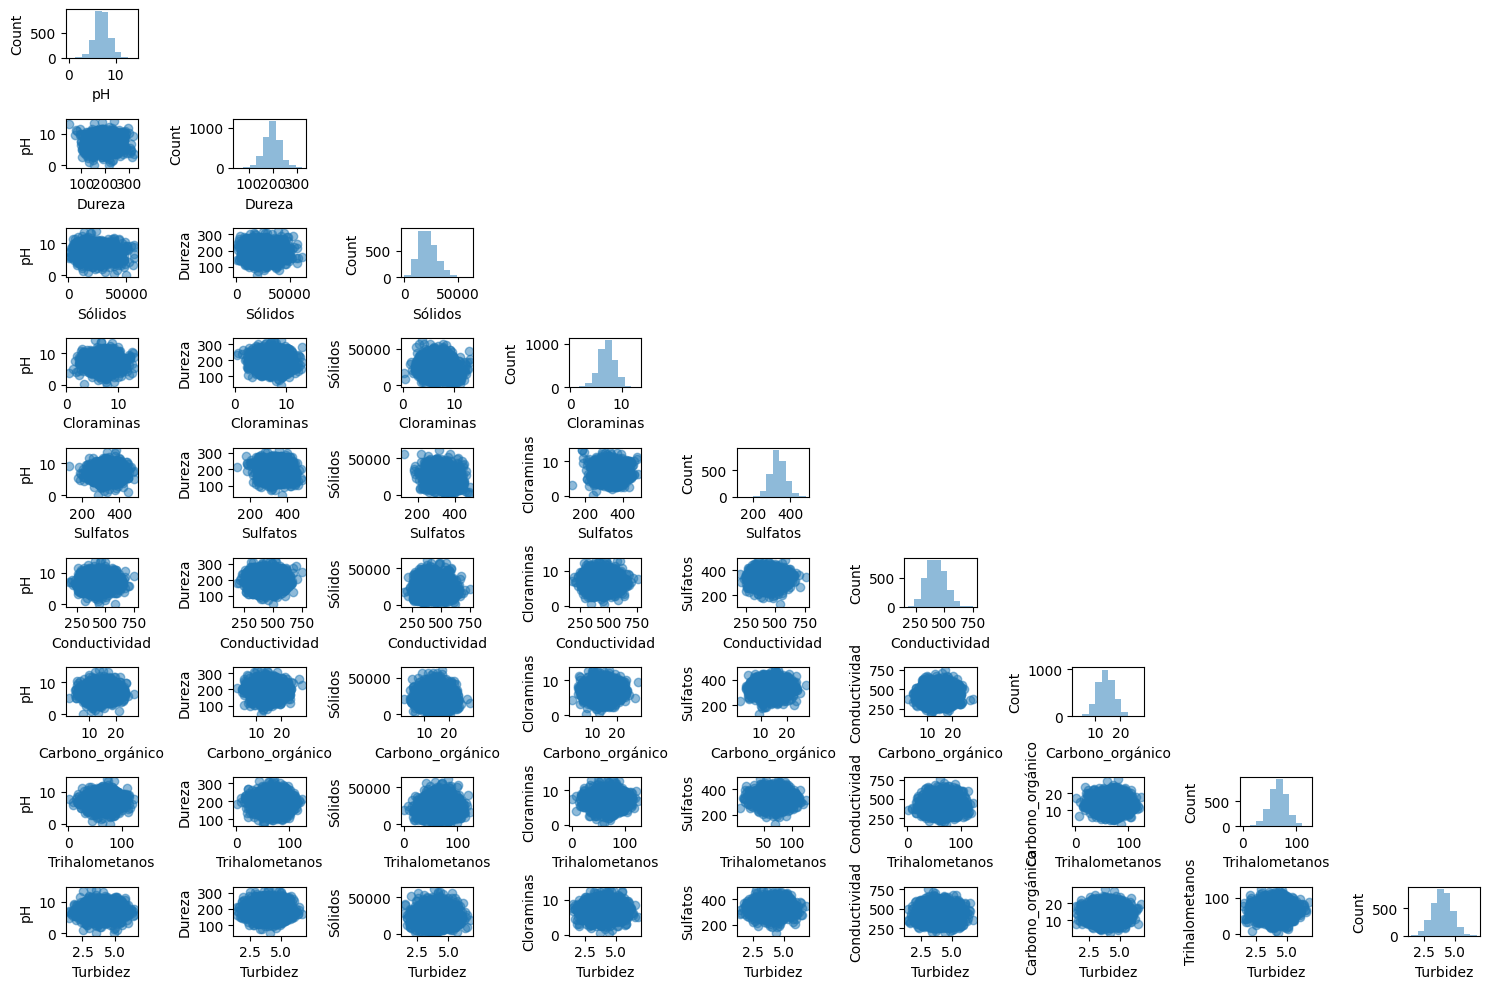

In [ ]:
#Definimos una nueva variable para almacenar la variable que vamos a diseñar con graficos de dispersión. Esto para las variable cuantitativas.
cols_scatter = ['pH','Dureza','Sólidos','Cloraminas','Sulfatos','Conductividad','Carbono_orgánico','Trihalometanos','Turbidez']
scatterplotmatrix(datos_crudos[cols_scatter].values, figsize=(15, 10),
  names=cols_scatter, alpha=0.5)
plt.tight_layout()
plt.show()

Como comentario de las graficas anteriores se observan como los valores faltantes afetan la distribución de variables como PH, Sultatos etc las cuales fueron mencionadas anteriormente.

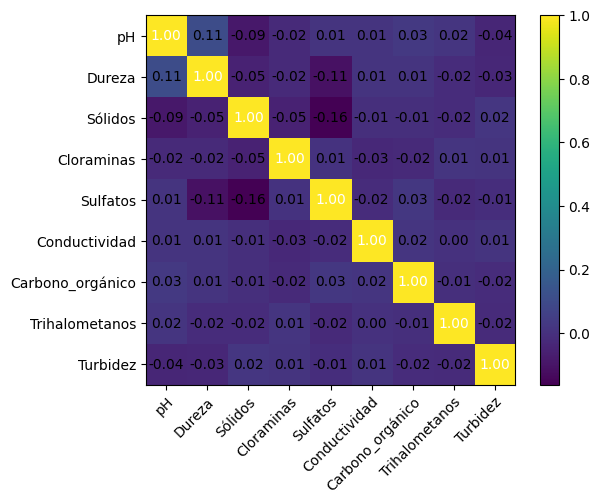

In [ ]:
datos_crudos_no_vacios = datos_crudos.dropna()                        #Preparacion de set temporal para propositos de construir mapa de calor
cm = np.corrcoef(datos_crudos_no_vacios[cols_scatter].values.T)
hm = heatmap(cm,row_names=cols_scatter, column_names=cols_scatter)
plt.show()

Al hacer la correlacion entre las varaibles no existe correlación fuerte entre ellas, por lo que me lleva a concluir que todas la varaibles son independientes y deberian ser incluidas en el procesamiento de datos.

In [ ]:
#Copiamos el dateset en otro para procesar los datos faltantes, duplicados y eliminación de variables no relevantes
datos = datos_crudos.copy()


In [ ]:
# Como se habia mencionado Sulfato, PH y Trihalometanos, representan un conjunto de datos con faltantes.
datos.isna().sum()

,0
pH,491
Dureza,0
Sólidos,0
Cloraminas,0
Sulfatos,781
Conductividad,0
Carbono_orgánico,0
Trihalometanos,162
Turbidez,0
Potabilidad,0


Conclusiones.
- La imputación de datos será esencial para manejar los valores faltantes y mejorar la precisión del análisis de la calidad del agua. Tambien será importante utilizar una combinación de estrategias de imputación para abordar los diferentes tipos de variables y sus características. Además, es crucial validar la imputación realizada para asegurar que los datos imputados no introduzcan sesgos o errores en el modelo.
- Será crucial no realizar el borrado de variables con datos faltantes, ya que cada variable proporciona información valiosa y única sobre la calidad del agua. En lugar de eliminar variables, se utilizarán técnicas de imputación de datos para manejar los valores faltantes y mantener la integridad del análisis. Esto garantizará una evaluación más precisa y completa de la potabilidad del agua.
- Transformar datos categóricos a numéricos será necesario para garantizar la compatibilidad con los algoritmos de arboles y k-mmeans, para mejorar la precisión del modelo y facilitar el análisis estadístico

# **2. Limpieza y preparación de los datos con uso de pipeline**

In [ ]:
#No se encontraron datos duplicados
datos_crudos.duplicated().sum()

0

División de Datos

In [ ]:
# Se dividen los datos de entrenamiento y prueba
train, test = train_test_split(datos, test_size=0.2, random_state=77)
train = train.reset_index(drop=True)
test = test.reset_index(drop=True)
train.head()

,pH,Dureza,Sólidos,Cloraminas,Sulfatos,Conductividad,Carbono_orgánico,Trihalometanos,Turbidez,Potabilidad
0,6.67,155.71,30610.05,8.17,337.17,425.69,15.10,79.78,4.90,SI
1,6.26,130.37,9734.68,10.28,320.36,399.35,10.85,43.42,3.93,SI
2,6.66,182.39,16828.88,7.07,355.90,434.66,16.62,69.41,3.97,SI
3,8.02,255.26,30854.83,8.76,NaN,442.50,11.09,93.27,5.32,SI
4,8.92,207.52,13291.92,8.56,357.94,468.54,15.69,107.28,4.08,NO


In [ ]:
#Se preparan los datos para el entrenamiento y sacamos la variable independiente de este dataset
x_train = train.drop(['Potabilidad'], axis=1)
y_train = train['Potabilidad']

Imputación de datos

In [ ]:
#Como la variable dependiente tiene valores categoricos, se utiliza la función LabelEncoder para tranforma a valores numericos esta variable.
label_encoder = LabelEncoder()
y_train_transformed = label_encoder.fit_transform(y_train)
y_train_transformed = pd.DataFrame(y_train_transformed, columns=['Potabilidad'])

In [ ]:
#Inicia el proceso de Inputación.
num_imputer = SimpleImputer()
cat_imputer = SimpleImputer()

In [ ]:
# Variables numéricas: su tipo es entero o flotante
numeric_features = list(x_train.select_dtypes(include=[int,float]).columns)
# Variables categóricas: su tipo no es numérico
categorical_features = list(x_train.select_dtypes(exclude=[int,float]).columns)

In [ ]:
#Definción del proceso de imputación
imputer = ColumnTransformer(
    transformers=[
    # your code here
        ("num", num_imputer, numeric_features),
        ("cat", cat_imputer, categorical_features)
    ],
    verbose_feature_names_out=False
)


Estandarización - Bedido que para arboles de decision no es necesaria la transformación, entonces no es considerado este proceso.

Transformación de las variables categoricas - Solo se encontro que la variable dependiente es la que requeire un proceso de transofmracion de No y Si a 0 y 1 corespondientemente.

# 3. Construcción de un modelo de árboles de decisión


In [ ]:
decision_tree = DecisionTreeClassifier(random_state=0)

In [ ]:
#Definición de pasos para el pipeline del arbol de decisión
steps = [
    ("imputer", imputer),
    ("model", decision_tree),
]

In [ ]:
#Validación cruzada para el entrenamiento
kfold = KFold(n_splits=10, shuffle=True, random_state=0)

In [ ]:
#Definición del pipeline usando los pasos defindos anteriormente
pipeline = Pipeline(steps)
pipeline.set_output(transform="pandas")
pipeline

Pipeline(steps=[('imputer',
                 ColumnTransformer(transformers=[('num', SimpleImputer(),
                                                  ['pH', 'Dureza', 'Sólidos',
                                                   'Cloraminas', 'Sulfatos',
                                                   'Conductividad',
                                                   'Carbono_orgánico',
                                                   'Trihalometanos',
                                                   'Turbidez']),
                                                 ('cat', SimpleImputer(), [])],
                                   verbose_feature_names_out=False)),
                ('model', DecisionTreeClassifier(random_state=0))])

In [ ]:
#Definción de parametros del arbol de decisión
valores_imputer = ['mean', 'median']
valores_criterion = ['entropy', 'gini']
valores_max_depth = [4,6,8,10,12]
valores_min_samples_split = [3, 4, 5]
valores_class_weight = ['balanced']
param_grid = {
    'imputer__num__strategy': valores_imputer,
    'model__criterion': valores_criterion,
    'model__max_depth': valores_max_depth,
    'model__min_samples_split': valores_min_samples_split,
    'model__class_weight': valores_class_weight
}

In [ ]:
#Definción del grid para la busqueda del mejor hiperparametros del modelo de arbol de decisión
grid_arboles = GridSearchCV(pipeline, param_grid, cv=kfold, n_jobs=-1, scoring = "accuracy")

In [ ]:
#Ajuste de la varaible de busqueda de hiperparametros
grid_arboles.fit(x_train, y_train_transformed)

GridSearchCV(cv=KFold(n_splits=10, random_state=0, shuffle=True),
             estimator=Pipeline(steps=[('imputer',
                                        ColumnTransformer(transformers=[('num',
                                                                         SimpleImputer(),
                                                                         ['pH',
                                                                          'Dureza',
                                                                          'Sólidos',
                                                                          'Cloraminas',
                                                                          'Sulfatos',
                                                                          'Conductividad',
                                                                          'Carbono_orgánico',
                                                                          'Trihalometanos',
                                                                          'Turbidez']),
                                                                        ('cat',
                                                                         SimpleImputer(),
                                                                         [])],
                                                          verbose_feature_names_out=False)),
                                       ('model',
                                        DecisionTreeClassifier(random_state=0))]),
             n_jobs=-1,
             param_grid={'imputer__num__strategy': ['mean', 'median'],
                         'model__class_weight': ['balanced'],
                         'model__criterion': ['entropy', 'gini'],
                         'model__max_depth': [4, 6, 8, 10, 12],
                         'model__min_samples_split': [3, 4, 5]},
             scoring='accuracy')

In [ ]:
#Impresión de los mejores hiperparametros encontrados con Gridsearch
print("Mejores parámetros: {}".format(grid_arboles.best_params_))

Mejores parámetros: {'imputer__num__strategy': 'mean', 'model__class_weight': 'balanced', 'model__criterion': 'entropy', 'model__max_depth': 4, 'model__min_samples_split': 3}


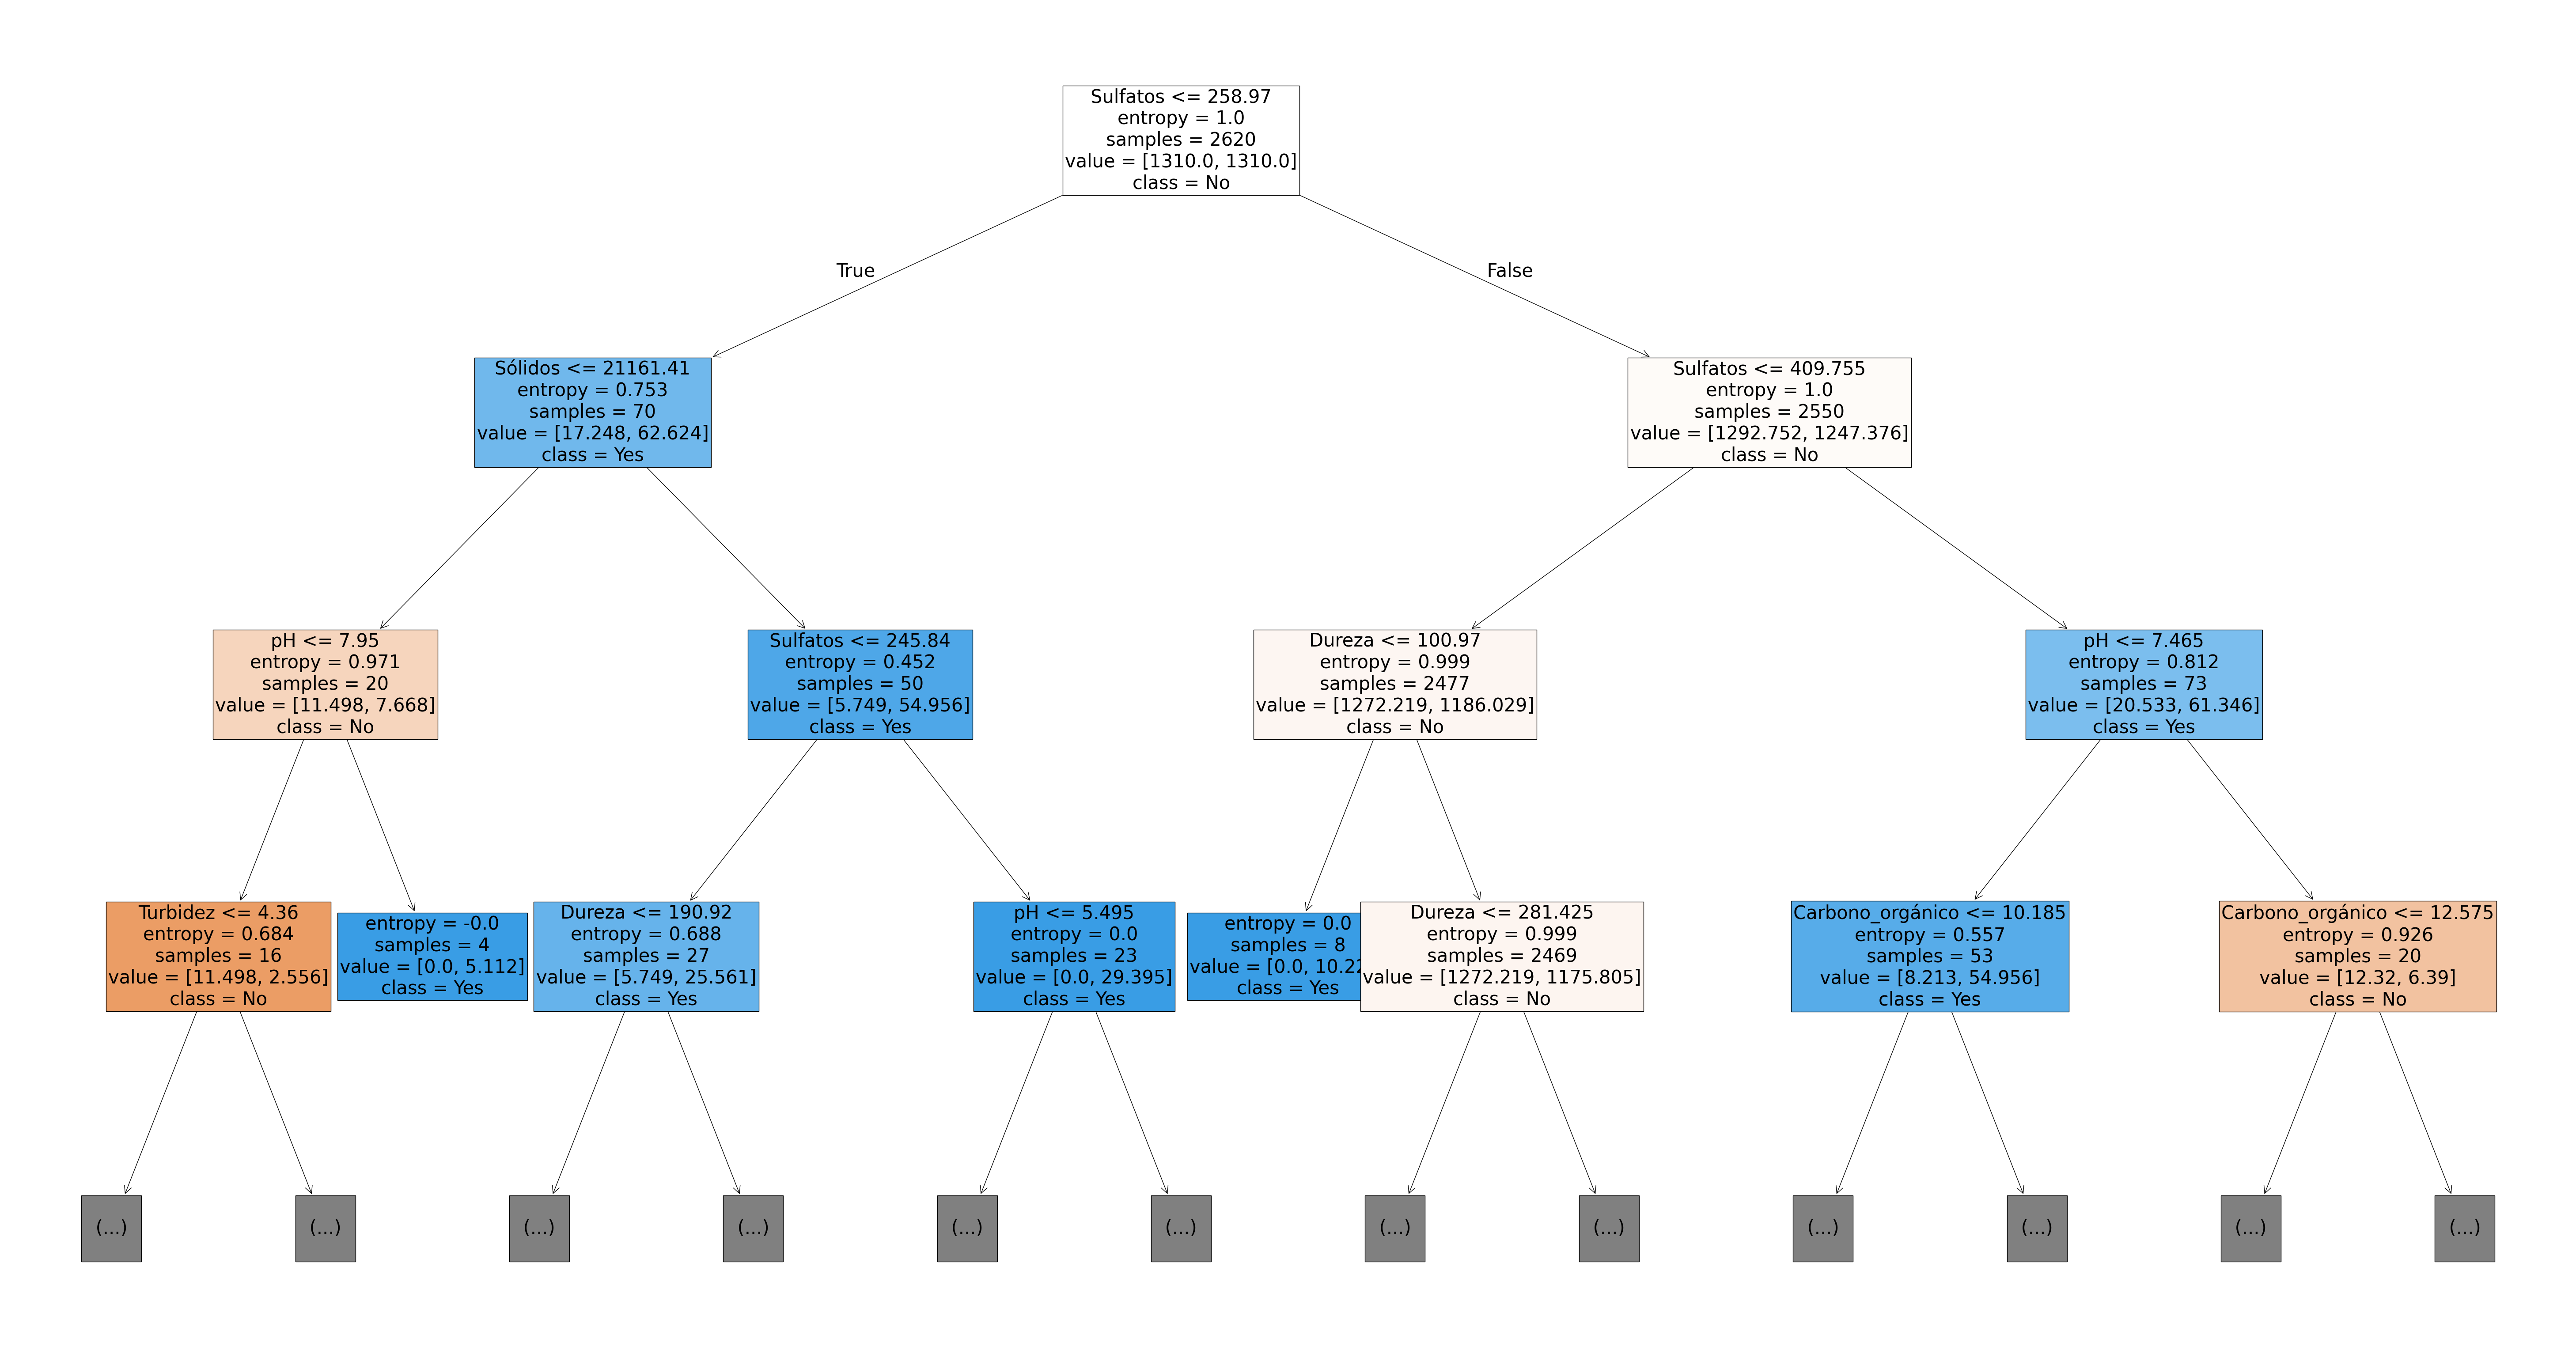

In [ ]:
mejor_modelo = grid_arboles.best_estimator_
plt.figure(figsize=(75,40))
tree = plot_tree(mejor_modelo[1], feature_names=x_train.columns, class_names=['No','Yes'], filled=True, fontsize=30, max_depth=3)

Las reglas de decisión que indican cuando el agua nos es potable para una profundidad de 3 son:
Si los sulfatos son mayores a 258.97:



Si los sulfatos son menores o iguales a 258,97:


In [ ]:
#Extraemos la siginificacia de las varaibles
importancia = mejor_modelo[1].feature_importances_
importancia_df = pd.DataFrame(data={'Variable':x_train.columns, 'Importancia':importancia})
importancia_df.sort_values('Importancia', ascending=False)

,Variable,Importancia
4,Sulfatos,0.352945
1,Dureza,0.195171
0,pH,0.187772
2,Sólidos,0.114988
6,Carbono_orgánico,0.103673
8,Turbidez,0.045451
3,Cloraminas,0.000000
5,Conductividad,0.000000
7,Trihalometanos,0.000000


El anterior listado nos permite asegurar que es fundamental que la imputación de la variable de sultatos se pueda realizar  el mejor metodo. Utilizaremos el metodo de Gridsearch para encontrar cual es el mejor parametros de imputación por ejemplo media, moda u otra. Por otro lado aunque existen variables con poca significancia, al realizar el ejercicio de su eliminación no hay ninguna ganancia en su eliminación asi que se define conservarlas.


Evaluación del mejor modelo

In [ ]:
#Transformación de las variables independientes para su imputación usando el mismo pipiline de entrenamiento para el dataset de test
x_test = test.drop(['Potabilidad'],axis=1)
y_test = pd.DataFrame(test['Potabilidad'])
x_test_transformed = grid_arboles.best_estimator_.named_steps['imputer'].transform(x_test)

In [ ]:
#Tranformación de las variable independiente de valores categoricos a numericos del dataset
y_test_transformed = label_encoder.transform(y_test.values.ravel())
y_test_transformed = pd.DataFrame(y_test_transformed, columns=['Potabilidad'])

In [ ]:
#Matriz de confusion
y_pred = mejor_modelo.predict(x_test_transformed)

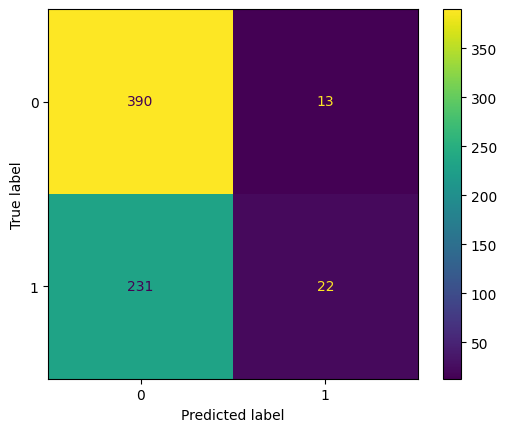

In [ ]:
ConfusionMatrixDisplay.from_estimator(mejor_modelo, x_test_transformed, y_test_transformed)
plt.show()

In [ ]:
#Metricas del arbol de decisión
arbol_metrics_report = classification_report(y_test_transformed, y_pred)
print(classification_report(y_test_transformed, y_pred))

              precision    recall  f1-score   support

           0       0.63      0.97      0.76       403
           1       0.63      0.09      0.15       253

    accuracy                           0.63       656
   macro avg       0.63      0.53      0.46       656
weighted avg       0.63      0.63      0.53       656



# 4. Construcción de un modelo utilizando el algoritmo K-vecinos más cercanos

A diferencia de los arboles de decision, aqui si es necesario realizar estandarización de la variables.

In [ ]:
pipeline_knn = Pipeline([
    ('imputer', SimpleImputer(strategy='mean')),             # Imputación numérica
    ('scaler', StandardScaler()),             # Estandarización
    ('knn', KNeighborsClassifier())           # Modelo KNN
])

In [ ]:
param_grid = {
    'imputer__strategy': ['mean', 'median'],      # Imputación: media o mediana
    'knn__n_neighbors': [1, 2, 3, 4, 5],         # Vecinos (k)
    'knn__weights': ['uniform', 'distance'],      # Pesos: uniforme o por distancia
    'knn__metric': ['euclidean', 'manhattan']     # Métricas de distancia
}

In [ ]:
grid_search = GridSearchCV(
    estimator=pipeline_knn,
    param_grid=param_grid,
    cv=5,                  # Validación cruzada con 5 folds
    scoring='accuracy',     # Métrica de evaluación
    n_jobs=-1,              # Usar todos los núcleos disponibles
    verbose=1               # Nivel de detalle en el output
)

In [ ]:
grid_search.fit(x_train, y_train_transformed)

Fitting 5 folds for each of 40 candidates, totalling 200 fits


/usr/local/lib/python3.11/dist-packages/sklearn/neighbors/_classification.py:239: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)


GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('imputer', SimpleImputer()),
                                       ('scaler', StandardScaler()),
                                       ('knn', KNeighborsClassifier())]),
             n_jobs=-1,
             param_grid={'imputer__strategy': ['mean', 'median'],
                         'knn__metric': ['euclidean', 'manhattan'],
                         'knn__n_neighbors': [1, 2, 3, 4, 5],
                         'knn__weights': ['uniform', 'distance']},
             scoring='accuracy', verbose=1)

In [ ]:
# Mostrar los mejores hiperparámetros
print("Mejores hiperparámetros encontrados:", grid_search.best_params_)
print("Mejor puntuación (accuracy):", grid_search.best_score_)

Mejores hiperparámetros encontrados: {'imputer__strategy': 'median', 'knn__metric': 'euclidean', 'knn__n_neighbors': 2, 'knn__weights': 'uniform'}
Mejor puntuación (accuracy): 0.632824427480916


In [ ]:
# Obtener el mejor número de vecinos (k)
best_k = grid_search.best_params_['knn__n_neighbors']

print(f"El mejor número de vecinos (k) encontrado es: {best_k}")

El mejor número de vecinos (k) encontrado es: 2


In [ ]:
# Extraer los mejores hiperparámetros encontrados
best_k = grid_search.best_params_['knn__n_neighbors']
best_strategy = grid_search.best_params_['imputer__strategy']
best_weights = grid_search.best_params_['knn__weights']
best_metric = grid_search.best_params_['knn__metric']

In [ ]:
# Crear el pipeline final con los mejores hiperparámetros
pipeline_final = Pipeline([
    ('imputer', SimpleImputer(strategy=best_strategy)),
    ('scaler', StandardScaler()),
    ('knn', KNeighborsClassifier(n_neighbors=best_k, weights=best_weights, metric=best_metric))
])

In [ ]:
# Reentrenar el modelo con TODOS los datos
pipeline_final.fit(x_train, y_train_transformed)

/usr/local/lib/python3.11/dist-packages/sklearn/neighbors/_classification.py:239: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)


Pipeline(steps=[('imputer', SimpleImputer(strategy='median')),
                ('scaler', StandardScaler()),
                ('knn',
                 KNeighborsClassifier(metric='euclidean', n_neighbors=2))])

In [ ]:
print(f"Modelo reentrenado con k={best_k}, strategy={best_strategy}, weights={best_weights}, metric={best_metric}")

Modelo reentrenado con k=2, strategy=median, weights=uniform, metric=euclidean


In [ ]:
y_pred_knn = pipeline_final.predict(x_test)

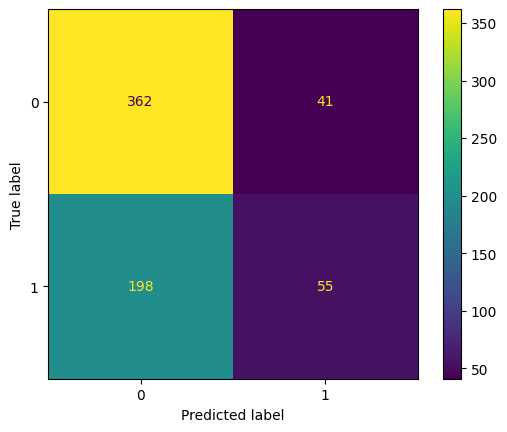

In [ ]:
ConfusionMatrixDisplay.from_estimator(pipeline_final, x_test_transformed, y_test_transformed)
plt.show()

In [ ]:
Kmeans_metrics_report = classification_report(y_test_transformed, y_pred_knn)
print(classification_report(y_test_transformed, y_pred_knn))

              precision    recall  f1-score   support

           0       0.65      0.90      0.75       403
           1       0.57      0.22      0.32       253

    accuracy                           0.64       656
   macro avg       0.61      0.56      0.53       656
weighted avg       0.62      0.64      0.58       656



# 5. Elaboración de una tabla comparativa

mostrando el rendimiento sobre test de los dos modelos seleccionados (con mejores rendimientos) de las actividades 3 y 4, sobre las métricas exactitud, recall, precisión y F-score

In [ ]:
print("Metricas del Modelos Arboles de Desición\n",arbol_metrics_report)
print("Metricas del Modelos Kmenas\n",Kmeans_metrics_report)


Metricas del Modelos Arboles de Desición
               precision    recall  f1-score   support

           0       0.63      0.97      0.76       403
           1       0.63      0.09      0.15       253

    accuracy                           0.63       656
   macro avg       0.63      0.53      0.46       656
weighted avg       0.63      0.63      0.53       656

Metricas del Modelos Kmenas
               precision    recall  f1-score   support

           0       0.65      0.90      0.75       403
           1       0.57      0.22      0.32       253

    accuracy                           0.64       656
   macro avg       0.61      0.56      0.53       656
weighted avg       0.62      0.64      0.58       656



# 6. Generación de las reglas de nivel 3

genera las reglas que nos permitan determinar cuándo el agua no es apta para el consumo (utiliza una profundidad de 3)

**Regla numero 1.**
Nodo Principal:
Condición: Si los sulfatos son menores o iguales a 258.97 mg/L, Y
Nodo Izquierdo (Nivel 1):
Condición: Si los sólidos son menores o iguales a 21161.41 mg/L, Y
Nodo Izquierdo (Nivel 2):
Condición: Si el pH es menor o igual a 7.95, Y
Resultado: **El agua no es apta para el consumo con un de  (Clase: No).**
Nodo Izquierdo (Nivel 3)
Condición: Si la Tubidex menor o igual a 4.36, existe una probabilidad **del 71.86% de que el agua no sea apta para el consumo humano.**

**Regla numero 2.**
Nodo Principal:
Condición: Si los sulfatos son mayores a 258.97 mg/L, Y
Nodo Derecho (Nivel 1):
Condición: Si los Sulfatos son menores o iguales a 409.755 mg/L, Y
Nodo Izquierdo (Nivel 2):
Condición: Si la Dureza son menores o iguales a 100.97 mg/L, Y
Nodo Derecho (Nivel 3):
Condición: Si Dureza es menor o igual a 281.425, **existe una probabilida de 51,52% de que el agua no sea apta para el consumo humano **

**Regal numero 3.**
Nodo Principal:
Condición: Si los sulfatos son mayores a 258.97 mg/L, Y
Nodo Derecho (Nivel 1):
Condición: Si los Sulfatos son mayores a 409.755 mg/L, Y
Nodo Derecho (Nivel 2):
Condición: Si el PH es mayor que 7.465, Y
Nodo Derecho (Nivel 3):
Condición: Si Carbono Organico es menor o igual 12.575, **existe una probabilidad de 61,6% de que el auga no sea apta para el consumo huma**no.



Una vez construido los modelos, deberías estar en capacidad de responder estas preguntas:

**¿Qué puedes decir de los valores de las métricas recall y precisión para cada una de las clases en cada modelo?**

**Respuesta:** Basados en el planteamiento del problema, el cual aborda un proyecto relacionado con la gestión ambiental, es crucial considerar tanto la clase "No potable" como la clase "Potable" en el contexto de predecir si una toma de agua es potable o no:

**Clase 0 (No potable):** El recall es la métrica más importante para asegurar que la mayoría de las tomas de agua no potables sean identificadas correctamente. El modelo de árbol de decisión tiene un mejor desempeño en esta métrica.
**Clase 1 (Potable):** Aunque el recall es bajo en ambos modelos, el modelo K-means tiene un mejor desempeño en esta métrica. Sin embargo, la precisión es ligeramente mejor en el modelo de árbol de decisión.
En resumen, para proteger la salud pública, es fundamental priorizar el recall para la clase "No potable". El modelo de árbol de decisión es preferible en este caso debido a su alto recall para la clase "No potable". Sin embargo, también es importante trabajar en mejorar el recall para la clase "Potable" en ambos modelos para asegurar una clasificación más equilibrada y precisa.

**¿Cuál de estás métricas consideras que es más importante con base en la descripción del problema?**
**Respuesta:** Ver analisis preliminar.

**¿Consideras que el rendimiento de los modelos es adecuado?**

**Respuesta:** El rendimiento actual de los modelos muestra que hay margen de mejora, especialmente en la identificación de tomas de agua potables. Implementar algunas de las alternativas  puede ayudar a mejorar el rendimiento general y asegurar una clasificación más precisa y equilibrada

**Si no es así, ¿Cómo podrían mejorarse los resultados?**
**Respuesta:** Alternativas para Mejorar el Rendimiento

*Ajuste de Hiperparámetros:*

En ambos casos fueron ejecutados técnicas de seleccion de modelos con GridSearch, probandos varias alternativas de hiperparametros. Se confirma que esta alternativa ya fue realizada.

*Modelos de Ensamble:*

Random Forest: Opcionalmente se podrian probar múltiples árboles de decisión para mejorar la precisión.
Gradient Boosting: Podria Mejorar el rendimiento del modelo mediante la combinación de múltiples modelos débiles.

*Imputación de Valores Faltantes:* Alternativa realizada dentro del proyecto (sulfatos, pH, trihalometanos).
*Normalización/Estandarización:* Alternativa realizada dentro del proyecto.

*Ingeniería de Características:*
Dentro del proyecto se realizo un ejercio intentando agrupar las variable por tipo (quimicas, ficias, etc). El resultado al que se llego fue que no se encontro ninguna mejora en el accuracy del modelo por lo cual fue descartada esta alternativa.

*Creación de Nuevas Características: *Generar nuevas características a partir de las existentes que puedan capturar mejor la variabilidad en los datos.
*Selección de Características:* Dentro del proyecto se analizo desde el punto de vista técnico la relevacia de las varaibles. Aun asi no se encontro ningun critero importante para elminar o seleccionar variables constantes, indeces u otros de forma manual. Sería importe complementar este analisis haciendolo con un apoyo o retroalimentación con los dueños de los datos.

*Balanceo de Clases:*

Sobremuestreo: Podria ser una alternativa aumentar el número de muestras de la clase minoritaria (potable) utilizando técnicas como SMOTE (Synthetic Minority Over-sampling Technique).
Submuestreo: Reduce el número de muestras de la clase mayoritaria (no potable) para equilibrar las clases. Dentro del proyeto se considero el hiperparametro valores_class_weight intentando mejor el balanceo de clases aunque no se observo mayor mejora.

*Validación Cruzada:*

Inlcuida dentro del proyecto usando la funcion de Kfold.

**¿Cuáles son las variables más significativas según el mejor modelo basado en árboles de decisión?**
Respuesta, Sulfatos, Dureza y PH.

**Reflexiona sobre cómo este nuevo conocimiento podría ayudar a tomar decisiones en el contexto del problema.**
Es importante asegurar la calidad de los datos en estas variables, ya que como se menciono anteriomente, datos faltantes podran afectar el valor de la muestra total.

**Si los dos modelos proporcionan resultados similares en cuanto a las métricas de rendimiento ¿Cuál seleccionarías tomando en cuenta el contexto del problema?**

Si ambos modelos proporcionan resultados similares en cuanto a las métricas de rendimiento, la elección del modelo puede depender de varios factores adicionales, incluyendo la interpretabilidad, la facilidad de implementación, y el contexto específico del problema.

Árbol de Decisión: Dado que la calidad del agua es un tema crítico para la salud pública, la interpretabilidad del modelo es crucial. Los árboles de decisión permiten a los expertos en agua y salud pública entender y confiar en las decisiones del modelo, lo que facilita la adopción y la implementación de medidas correctivas.
K-means: Aunque puede ser útil para identificar patrones en los datos, la falta de interpretabilidad puede ser una desventaja en este contexto. Los expertos pueden encontrar difícil confiar en un modelo que no proporciona una explicación clara de sus decisiones.

Tomando en cuenta el contexto del problema, donde la calidad del agua y la salud pública son de suma importancia, seleccionaría el modelo de árbol de decisión. Su alta interpretabilidad y facilidad de implementación lo hacen más adecuado para este tipo de problema, permitiendo a los expertos entender y actuar sobre las decisiones del modelo de manera efectiva. Lo anterior mas el anlisis de metricas realizado anteriormente.